# Swarm data visualization

Using GeospaceLAB, users can make time-series plots and geospatial maps for the variables loaded in one or multiple datasets. This process is managed by the GeospaceLAB Visualization component, which includes three base classes:
- `Figure`: The top level container for all plotting elements (dashboards, panels, axes),  which is an inheritance of `matplotlib.figure.Figure`,
- `Dashboard`: The second level container that is composed of one or more panels.
- `Panel`: The base level container that is composed of one or more `matplotlib` axes. The major axes is used for plotting, and support axes can be colorbars, legends, and others.

In [1]:
import datetime
import geospacelab.visualization.mpl as gsl_mpl


## Time-series plots

The `Dashboard` classs and its subclasses (e.g. TSDashboard for time-series plots) are the core component to manage the plots. The `Dashboard` class is also an insheritance of GeospaceLAB `DataHub` and hence it can be used as a data manager. For example, to dock a dataset, call the `dock` method directly from a `Dashboard` object.

### 1-D and 2-D time-series plots from a single dataset

In [2]:
# Initialize the time range and satellite ID for data retrieval and visualization
dt_fr = datetime.datetime(2016, 3, 15, 2, 34)
dt_to = datetime.datetime(2016, 3, 15, 2, 51)
sat_id = "A"

Load IGRF coefficients ...


Searching the data product "MAG_LR" with the version "latest" on the server...
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_LR/0701/Sat_A/2016/SW_OPER_MAGA_LR_1B_20160315T000000_20160315T235959_0701_MDR_MAG_LR.cdf'), PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_LR/0701/Sat_A/2016/SW_OPER_MAGA_LR_1B_20160315T000000_20160315T235959_0701_ASM_VFM_IC.cdf')] already exists: skip downloading.
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


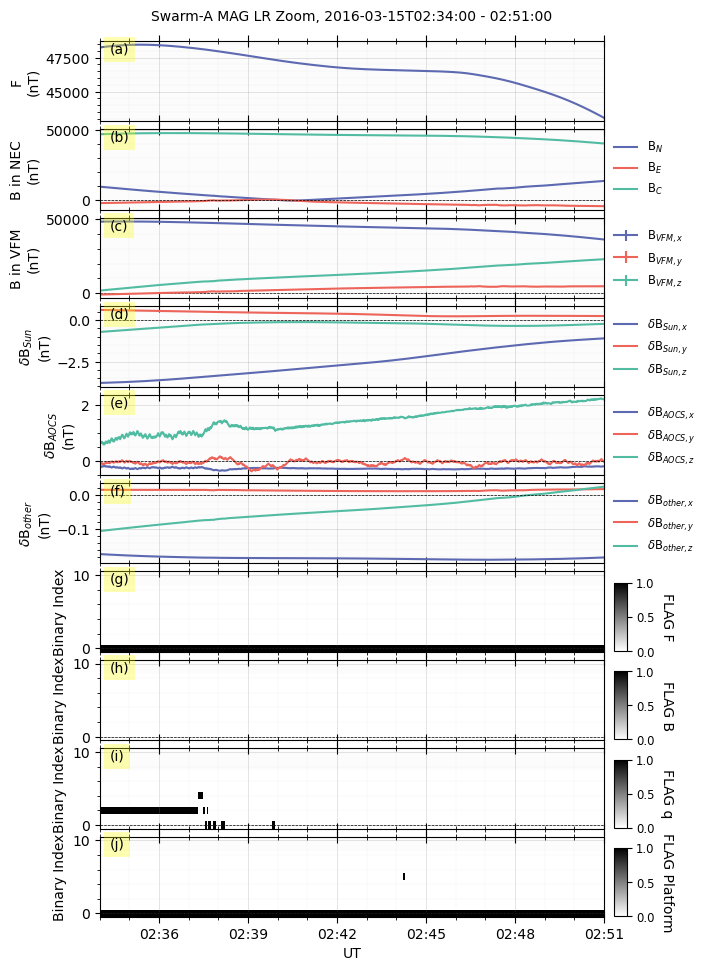

In [3]:

# Create a figure
fig = gsl_mpl.create_figure(figsize=(8, 12))
# Add a time series dashboard to the figure
db = gsl_mpl.dashboards.TSDashboard(figure=fig, dt_fr=dt_fr, dt_to=dt_to)
# Dock a dataset
ds = db.dock(datasource_contents=['esa_eo', 'swarm', 'l1b', 'mag_lr'], sat_id=sat_id, add_APEX=True,)
# Set the panel layouts in the dashboard. 
# The layout is a list of lists, where each inner list represents a row of panels in the dashboard. 
# Each element in the inner list is a variable from the dataset that will be plotted in that panel.
# This allows for flexible arrangement of multiple plots in a single dashboard.
# To add or remove a panel, simply modify the inner lists accordingly. 
# For example, to remove the first panel, simply remove the first inner list: panel_layouts = [ [ds['B_N'], ds['B_E'], ds['B_C']], ... ]
panel_layouts = [
    [ds['F']],
    [ds['B_N'], ds['B_E'], ds['B_C']],
    [ds['B_VFM_x'], ds['B_VFM_y'], ds['B_VFM_z']],
    [ds['dB_Sun_VFM_x'], ds['dB_Sun_VFM_y'], ds['dB_Sun_VFM_z']],
    [ds['dB_AOCS_VFM_x'], ds['dB_AOCS_VFM_y'], ds['dB_AOCS_VFM_z']],
    [ds['dB_other_VFM_x'], ds['dB_other_VFM_y'], ds['dB_other_VFM_z']],
    [ds['FLAG_F_BIN_AUX']],
    [ds['FLAG_B_BIN_AUX']],
    [ds['FLAG_q_BIN_AUX']],
    [ds['FLAG_Platform_BIN_AUX']],
]
db.set_layout(panel_layouts)
# Plotting the data in the dashboard
db.draw()
# Add panel labels to the dashboard
db.add_panel_labels()
# Add a title to the dashboard
db.add_title(y=1.02,title='Swarm-{} MAG LR Zoom'.format(ds.sat_id), fontsize='medium', append_time=True)
# Show the figure/dashboard
db.show() 

The above figure shows different variables from the Swarm MAG LR products. The panel layouts can be changed flexibly. 

For example, to remove the panels of "F" and flags, remove the first inner list `[ds['F']],`, `[ds['FLAG_F_BIN_AUX']],`, `[ds['FLAG_B_BIN_AUX']],`, `[ds['FLAG_q_BIN_AUX']],`, and `[ds['FLAG_Platform_BIN_AUX']],`. 

Additionally, to remove one of the line plots (e.g., B_VFM_x) in panel c, change `[ds['B_VFM_x'], ds['B_VFM_y'], ds['B_VFM_z']],` to `[ds['B_VFM_y'], ds['B_VFM_z']],`.

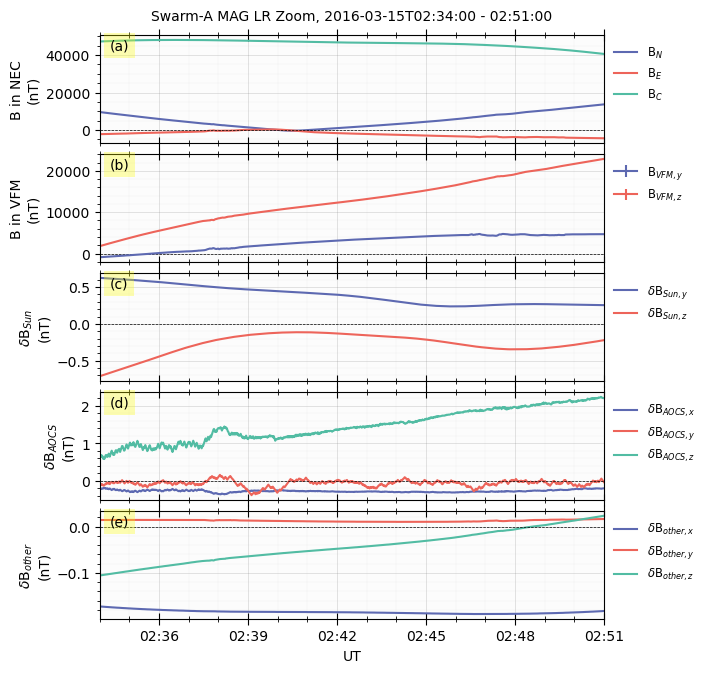

In [4]:
fig = gsl_mpl.create_figure(figsize=(8, 8))
db = gsl_mpl.dashboards.TSDashboard(figure=fig, dt_fr=dt_fr, dt_to=dt_to)
panel_layouts = [
    [ds['B_N'], ds['B_E'], ds['B_C']],
    [ds['B_VFM_y'], ds['B_VFM_z']],
    [ds['dB_Sun_VFM_y'], ds['dB_Sun_VFM_z']],
    [ds['dB_AOCS_VFM_x'], ds['dB_AOCS_VFM_y'], ds['dB_AOCS_VFM_z']],
    [ds['dB_other_VFM_x'], ds['dB_other_VFM_y'], ds['dB_other_VFM_z']],
]
db.set_layout(panel_layouts)
# Plotting the data in the dashboard
db.draw()
# Add panel labels to the dashboard
db.add_panel_labels()
# Add a title to the dashboard
db.add_title(y=1.02,title='Swarm-{} MAG LR Zoom'.format(ds.sat_id), fontsize='medium', append_time=True)
# Show the figure/dashboard
db.show() 

### Show satellite positions along the time axis

GeospaceLAB `TSDashboard` is also able to show the satellite positions along the time axis by setting the keyword `timeline_extra_labels` when the dashboard object is created.

Create a new figure: Figure(800x500).
INFO: Loading data from VirES for collection SW_OPER_MAGA_LR_1B with products {'measurements': ['B_VFM', 'B_NEC', 'dB_Sun', 'dB_AOCS', 'dB_other', 'B_error', 'q_NEC_CRF', 'Att_error', 'Flags_B', 'Flags_q', 'Flags_Platform', 'Flags_F', 'ASM_Freq_Dev', 'F', 'F_error', 'dF_Sun', 'dF_AOCS', 'dF_other'], 'models': ['CHAOS-Core'], 'residuals': True}.
Processing:  100%|██████████|  [ Elapsed: 00:00, Remaining: 00:00 ] [1/1] 
Downloading: 100%|██████████|  [ Elapsed: 00:00, Remaining: 00:00 ] (0.322MB)
INFO: Data loaded from VirES.
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


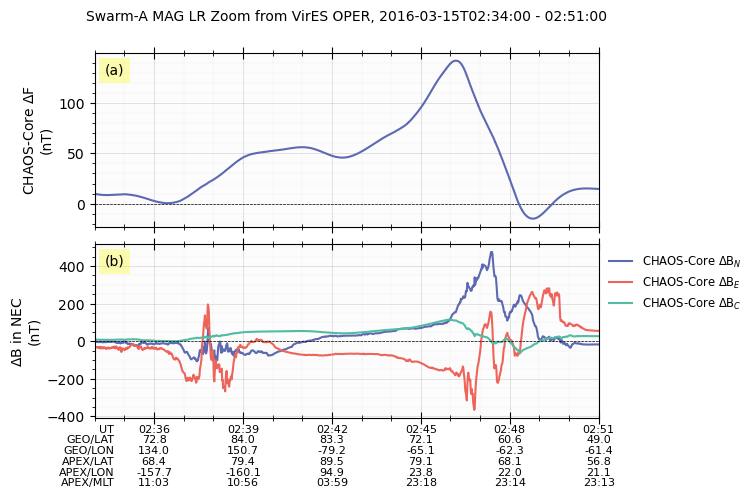

In [5]:
# Default kwargs for VirES data loading, which can be overridden when calling the dock method to load data from VirES. 
# The measurements, models, and residuals to load can be specified in the kwargs_products dictionary. 
# The default settings are for loading all available measurements and models, and no residuals. 
# The available measurements and models depend on the specific collection and product being loaded, 
# and can be checked in the VirES API documentation or by inspecting the variables in the loaded dataset.
kwargs_products_default = {
        "measurements": [
            'B_VFM', 'B_NEC', 'dB_Sun', 'dB_AOCS', 'dB_other', 'B_error',
            'q_NEC_CRF', 'Att_error',
            'Flags_B', 'Flags_q', 'Flags_Platform', 'Flags_F',
            'ASM_Freq_Dev', 'F', 'F_error', 'dF_Sun', 'dF_AOCS', 'dF_other',
        ],
        "models": [
            'CHAOS-Core',
        ],
        "residuals": True,
    }


db = gsl_mpl.dashboards.TSDashboard(
    dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (8, 5)},
    timeline_extra_labels=['GEO_LAT', 'GEO_LON', 'APEX_LAT', 'APEX_LON', 'APEX_MLT',] 
    )

ds_vires = db.dock(
    datasource_contents=['esa_eo', 'swarm', 'l1b', 'mag_lr'], 
    from_VirES=True, from_FAST=False,
    sat_id=sat_id, add_APEX=True,
    kwargs_VirES={"kwargs_products": kwargs_products_default},
)

panel_layouts = [
    [ds_vires['F_res_CHAOS-Core']],
    [ds_vires['B_res_CHAOS-Core_N'], ds_vires['B_res_CHAOS-Core_E'], ds_vires['B_res_CHAOS-Core_C']],
]

db.set_layout(panel_layouts=panel_layouts)
db.draw()
db.add_panel_labels()
db.add_title(title='Swarm-{} MAG LR Zoom from VirES OPER'.format(ds_vires.sat_id), fontsize='medium', append_time=True)
db.show()

### Combined time-series plots from multiple datasets

The following script show the figure combining data from three Swarm datasets, including 
- B in NEC coordinates in Swarm MAG LR, 
- disturbed B in NEC from Swarm MAG LR from Swarm VirES, 
- the field-aligned current from Swarm FAC LLS, 
- and the ion velocities from Swarm EFI TCT02 data. 

Searching the data product "MAG_LR" with the version "latest" on the server...
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_LR/0701/Sat_A/2016/SW_OPER_MAGA_LR_1B_20160315T000000_20160315T235959_0701_MDR_MAG_LR.cdf'), PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_LR/0701/Sat_A/2016/SW_OPER_MAGA_LR_1B_20160315T000000_20160315T235959_0701_ASM_VFM_IC.cdf')] already exists: skip downloading.
INFO: Loading data from VirES for collection SW_OPER_MAGA_LR_1B with products {'measurements': ['B_VFM', 'B_NEC', 'dB_Sun', 'dB_AOCS', 'dB_other', 'B_error', 'q_NEC_CRF', 'Att_error', 'Flags_B', 'Flags_q', 'Flags_Platform', 'Flags_F', 'ASM_Freq_Dev', 'F', 'F_error', 'dF_Sun', 'dF_AOCS', 'dF_other'], 'models': ['CHAOS-Core'], 'residuals': True}.
Processing:  100%|██████████|  [ Elapsed: 00:00, Remaining: 00:00 ] [1/1] 
Downloading: 100%|██████████|  [ Elapsed: 00:00, Remaining: 00:00 ] (0.322MB)
INFO: Data loaded from VirES.
/opt/anaconda3/envs/Swarm/lib/python3.12/

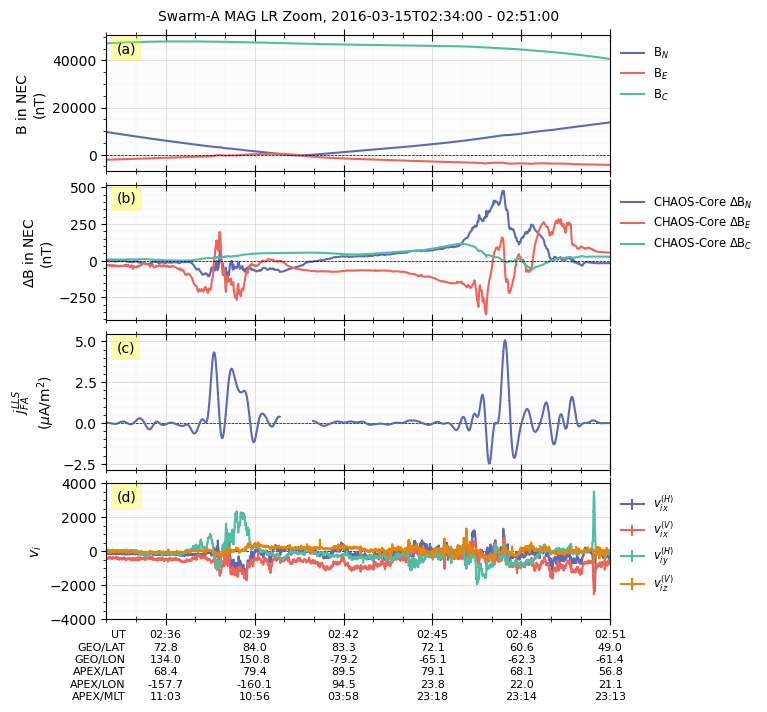

In [6]:
fig = gsl_mpl.create_figure(figsize=(8, 8))
db = gsl_mpl.dashboards.TSDashboard(
    figure=fig, dt_fr=dt_fr, dt_to=dt_to,
    timeline_extra_labels=['GEO_LAT', 'GEO_LON', 'APEX_LAT', 'APEX_LON', 'APEX_MLT',] 
    )
ds_mag = db.dock(
    datasource_contents=['esa_eo', 'swarm', 'l1b', 'mag_lr'], 
    sat_id=sat_id, 
    add_APEX=True,)
ds_vires = db.dock(
    datasource_contents=['esa_eo', 'swarm', 'l1b', 'mag_lr'], 
    from_VirES=True, from_FAST=False,
    sat_id=sat_id, add_APEX=True,
    kwargs_VirES={"kwargs_products": kwargs_products_default},
)
ds_FAC = db.dock(
    datasource_contents=['esa_eo', 'swarm', 'l2daily', 'fac_lls_dual'], 
    add_APEX=True,) # sat_id is fixed to 'AC' for LLS Dual product

ds_tct02 = db.dock(
    datasource_contents=['esa_eo', 'swarm', 'advanced', 'efi_tct02'], 
    sat_id=sat_id, add_APEX=True,
)

panel_layouts = [
    [ds_mag['B_N'], ds_mag['B_E'], ds_mag['B_C']],
    [ds_vires['B_res_CHAOS-Core_N'], ds_vires['B_res_CHAOS-Core_E'], ds_vires['B_res_CHAOS-Core_C']],
    [ds_FAC['j_FA']],
    [ds_tct02['v_i_H_x'], ds_tct02['v_i_V_x'], ds_tct02['v_i_H_y'], ds_tct02['v_i_V_z']],
]
db.set_layout(panel_layouts)
# Plotting the data in the dashboard
db.draw()
# Add panel labels to the dashboard
db.add_panel_labels()
# Add a title to the dashboard
db.add_title(y=1.02,title='Swarm-{} MAG LR Zoom'.format(ds.sat_id), fontsize='medium', append_time=True)
# Show the figure/dashboard
db.show() 

## Polar maps

The along-track data can be also plotted in polar maps in GeospaceLAB using `GeoDashboard`.

### Satellite trajectory

Create a new figure: Figure(500x500).
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/apexpy/apex.py:556: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  alat, alon = self._geo2apex(glat, glon, height)
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/apexpy/apex.py:559: UserWarning: Apex latitude set to NaN where undefined (apex height may be < reference height)
  warnings.warn(''.join(['Apex latitude set to NaN where undefined ',
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


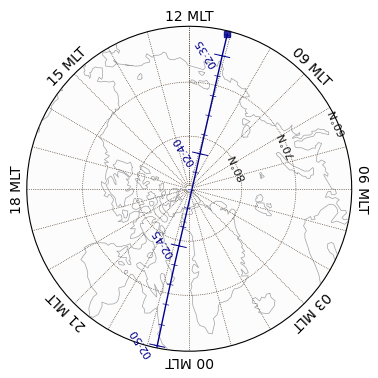

In [7]:
# Create a geodashboard object
db = gsl_mpl.geomap.geodashboards.GeoDashboard(dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (5, 5)})
# Set the layout of the geodashboard to have one panel that will display the satellite's trajectory on a map
db.set_layout(1, 1)     # Set the layout to have 1 row and 1 column, meaning there will be one panel in the geodashboard
# Add a polar map panel
time_c = dt_fr + (dt_to - dt_fr) / 2
panel = db.add_polar_map(
        row_ind=0, 
        col_ind=0, 
        style='mlt-fixed',  # 'glon-fixed', 'lst-fixed', or 'mlt-fixed'
        cs='APEX',
        mlt_c=0., 
        pole='N',   # 'N' for North Pole, 'S' for South Pole
        ut=time_c,  # The time when the satellite is close tot the pole, 
                    # used for calculating the magnetic coordinates and plotting the satellite trajectory on the polar map.
        boundary_lat=60., # The latitude of the boundary of the polar map. 
        mirror_south=True # Applicable when pole = 'S'
    )
# Add grids and labels to the polar map
panel.overlay_gridlines(lat_label_clock=2.2)
panel.overlay_coastlines()
# Show the satellite trajectory on the polar map using the coordinates from the ds_mag dataset
sc_dts = ds_mag['SC_DATETIME'].flatten()
sc_glats = ds_mag['SC_GEO_LAT'].flatten()
sc_glons = ds_mag['SC_GEO_LON'].flatten()
sc_alts = (ds_mag['SC_GEO_r'].flatten() - 1) * 6371.2  # Convert from Earth radii to km
sc_coords = {'lat': sc_glats, 'lon': sc_glons, 'height': sc_alts}

# Overlay the satellite trajectory with ticks
panel.overlay_sc_trajectory(
    sc_ut=sc_dts, 
    sc_coords=sc_coords, 
    cs='GEO', # Input coordinate system
    color='darkblue',
    time_tick = True, 
    time_tick_res=300., 
    time_tick_scale=0.05,
    time_tick_label=True, 
    time_tick_label_format="%H:%M", 
    time_tick_label_fontsize=8,
    time_tick_label_rotation=45., 
    time_tick_label_offset=0.05, 
    time_tick_label_fontweight='normal',
    time_minor_tick=True, 
    time_minor_tick_res=60,
    show_start_point=True,
    )

### Along-track data in multicolored line

Create a new figure: Figure(500x500).
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/apexpy/apex.py:556: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  alat, alon = self._geo2apex(glat, glon, height)
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/apexpy/apex.py:559: UserWarning: Apex latitude set to NaN where undefined (apex height may be < reference height)
  warnings.warn(''.join(['Apex latitude set to NaN where undefined ',
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


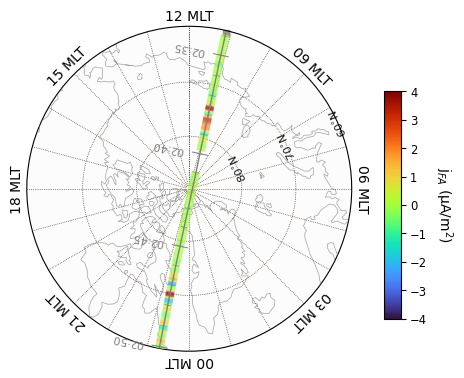

In [20]:
# Create a geodashboard object
db = gsl_mpl.geomap.geodashboards.GeoDashboard(dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (5, 5)})
# Set the layout of the geodashboard to have one panel that will display the satellite's trajectory on a map
db.set_layout(1, 1)     # Set the layout to have 1 row and 1 column, meaning there will be one panel in the geodashboard
# Add a polar map panel
time_c = dt_fr + (dt_to - dt_fr) / 2
panel = db.add_polar_map(
        row_ind=0, 
        col_ind=0, 
        style='mlt-fixed',  # 'glon-fixed', 'lst-fixed', or 'mlt-fixed'
        cs='APEX',
        mlt_c=0., 
        pole='N',   # 'N' for North Pole, 'S' for South Pole
        ut=time_c,  # The time when the satellite is close tot the pole, 
                    # used for calculating the magnetic coordinates and plotting the satellite trajectory on the polar map.
        boundary_lat=60., # The latitude of the boundary of the polar map. 
        mirror_south=True # Applicable when pole = 'S'
    )
# Add grids and labels to the polar map
panel.overlay_gridlines(lat_label_clock=2.2)
panel.overlay_coastlines()
# Show the satellite trajectory on the polar map using the coordinates from the ds_mag dataset
sc_dts = ds_FAC['SC_DATETIME'].flatten()
sc_glats = ds_FAC['SC_GEO_LAT'].flatten()
sc_glons = ds_FAC['SC_GEO_LON'].flatten()
sc_alts = (ds_FAC['SC_GEO_r'].flatten() - 1) * 6371.2  # Convert from Earth radii to km
sc_coords = {'lat': sc_glats, 'lon': sc_glons, 'height': sc_alts}

# Get the FAC data from the ds_FAC dataset, which will be used for coloring the satellite trajectory on the polar map.
j_FA = ds_FAC['j_FA'].flatten()
# Overlay the FAC data on the satellite trajectory by passing it as the color argument in the overlay_sc_trajectory method.
icl = panel.overlay_sc_coloured_line(
    j_FA,
    sc_ut=sc_dts, 
    sc_coords=sc_coords, 
    cs='GEO', # Input coordinate system
    c_map = 'turbo',
    c_lim = [-4, 4],   
)
panel.add_colorbar(icl, c_label=r'j$_{FA}$ (µA/m$^2$)',)

# Overlay the satellite trajectory with ticks
panel.overlay_sc_trajectory(
    sc_ut=sc_dts, 
    sc_coords=sc_coords, 
    cs='GEO', # Input coordinate system
    color='gray',
    time_tick = True, 
    time_tick_res=300., 
    time_tick_scale=0.05,
    time_tick_label=True, 
    time_tick_label_format="%H:%M", 
    time_tick_label_fontsize=8,
    time_tick_label_rotation=90., 
    time_tick_label_offset=0.1, 
    time_tick_label_fontweight='normal',
    time_minor_tick=True, 
    time_minor_tick_res=60,
    show_start_point=True,
    )

### Cross-track vectors

Create a new figure: Figure(500x500).
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/apexpy/apex.py:556: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  alat, alon = self._geo2apex(glat, glon, height)
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/apexpy/apex.py:559: UserWarning: Apex latitude set to NaN where undefined (apex height may be < reference height)
  warnings.warn(''.join(['Apex latitude set to NaN where undefined ',
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


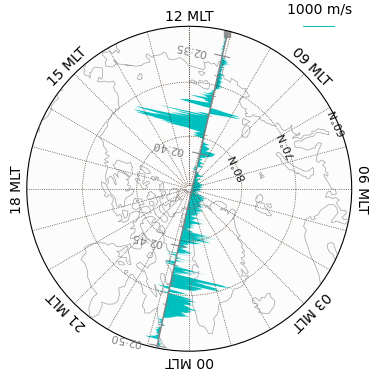

In [24]:
# Create a geodashboard object
db = gsl_mpl.geomap.geodashboards.GeoDashboard(dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (5, 5)})
# Set the layout of the geodashboard to have one panel that will display the satellite's trajectory on a map
db.set_layout(1, 1)     # Set the layout to have 1 row and 1 column, meaning there will be one panel in the geodashboard
# Add a polar map panel
time_c = dt_fr + (dt_to - dt_fr) / 2
panel = db.add_polar_map(
        row_ind=0, 
        col_ind=0, 
        style='mlt-fixed',  # 'glon-fixed', 'lst-fixed', or 'mlt-fixed'
        cs='APEX',
        mlt_c=0., 
        pole='N',   # 'N' for North Pole, 'S' for South Pole
        ut=time_c,  # The time when the satellite is close tot the pole, 
                    # used for calculating the magnetic coordinates and plotting the satellite trajectory on the polar map.
        boundary_lat=60., # The latitude of the boundary of the polar map. 
        mirror_south=True # Applicable when pole = 'S'
    )
# Add grids and labels to the polar map
panel.overlay_gridlines(lat_label_clock=2.2)
panel.overlay_coastlines()
# Show the satellite trajectory on the polar map using the coordinates from the ds_mag dataset
sc_dts = ds_tct02['SC_DATETIME'].flatten()
sc_glats = ds_tct02['SC_GEO_LAT'].flatten()
sc_glons = ds_tct02['SC_GEO_LON'].flatten()
sc_alts = (ds_tct02['SC_GEO_r'].flatten() - 1) * 6371.2  # Convert from Earth radii to km
sc_coords = {'lat': sc_glats, 'lon': sc_glons, 'height': sc_alts}

# Get the cross-track ion velocity data from the ds_tct02 dataset, which will be used for coloring the satellite trajectory on the polar map.
v_i_H_y = ds_tct02['v_i_H_y'].flatten()
# Overlay the cross-track ion velocity data on the satellite trajectory by passing it as the color argument in the overlay_sc_trajectory method.
panel.overlay_cross_track_vector(
        vector=-v_i_H_y.flatten(), unit_vector=1000, vector_unit='m/s', alpha=1, color='c', vector_width=1, 
        sc_coords=sc_coords, sc_ut=sc_dts, cs='GEO', shading='on', legend_pos_x=0.9, legend_pos_y=1
    )

# Overlay the satellite trajectory with ticks
panel.overlay_sc_trajectory(
    sc_ut=sc_dts, 
    sc_coords=sc_coords, 
    cs='GEO', # Input coordinate system
    color='gray',
    time_tick = True, 
    time_tick_res=300., 
    time_tick_scale=0.05,
    time_tick_label=True, 
    time_tick_label_format="%H:%M", 
    time_tick_label_fontsize=8,
    time_tick_label_rotation=90., 
    time_tick_label_offset=0.1, 
    time_tick_label_fontweight='normal',
    time_minor_tick=True, 
    time_minor_tick_res=60,
    show_start_point=True,
    )